# CFPB - Customer Complaint Analysis

The **Consumer Financial Protection Bureau** (CFPB) is a U.S. government regulatory agency established to protect consumers in the financial marketplace. The agency operates a centralized system where consumers can submit complaints regarding financial institutions, prompting the company to review and respond. 
According to the official 2025 statistics: *the CFPB received around $6.63M$ consumer complaints via its registered portal, toll-free number, postal mail, referrals from other regulatory bodies, etc., and routed around $5.98M$ complaints to over $4K$ companies for review with an expected response TAT of ${<}15days$.*\
These archived reports contain detailed EDA breakdown: [[annual-report_2025](https://www.consumerfinance.gov/data-research/research-reports/2025-consumer-response-annual-report/)].[[annual-report_2024](https://www.consumerfinance.gov/data-research/research-reports/2024-consumer-response-annual-report/)].[[annual-report_2023](https://www.consumerfinance.gov/data-research/research-reports/consumer-response-annual-report-2023/)].[[annual-report_2022](https://www.consumerfinance.gov/data-research/research-reports/2022-consumer-response-annual-report/)].[[annual-report_2021](https://www.consumerfinance.gov/data-research/research-reports/2021-consumer-response-annual-report/)]\
The portal states: <span style='font-family:'Courier New', monospace; font-style:italic;'>'Complaint narratives are consumers’ descriptions of their experiences in their own words'</span>; the CFPB only performs PII masking before uploading the narratives to the database. Consider the CFPB's description of the data collection process: <span style='font-family:'Courier New', monospace; font-style:italic;'>'The Consumer Complaint Database shows the consumer's original products, sub-products, issues, and sub-issues selections consistent with the options available on the form at the time the consumer submitted the complaint'</span>. i.e., the data annotation is performed by the individual customers themselves, not something directly actionable by CFPB staff.
<div style='border: 2px solid black; padding: 15px; font-size: 1.2em; font-weight: bold; border-radius: 5px; width: max-content;'>
    It is more sensible to spend effort understanding the themes and patterns within tagged complaints than trying to automatically assign those tags.
</div>



# Table of Contents

- [Extracting only the relevant data](#extracting-only-the-relevant-data)
- [Let's count...](#lets-count)
- [Can you read between the lines?](#can-you-read-between-the-lines)
- [After all, birds of a feather flock together.]
- [Those who don't fit anywhere, where do they go?]
- [A stitch in time saves nine.]


## Extracting only the relevant data
As of 21-June-2026, the CFPB [Consumer Complaint Database](https://www.consumerfinance.gov/data-research/consumer-complaints/search/?dateRange=All&date_received_max=2026-06-20&date_received_min=2011-12-01&page=1&searchField=all&size=25&sort=created_date_desc&tab=List) hosted around $16M$ records dating back to 2011. Instead of downloading the entire database dump, we pulled a 6-month window of data via the CFPB API after accounting for the portal's 15-day publishing lag. Only records with written narratives were retrieved, thereby excluding at the server level the $96\%$ of records within that timeframe that contained only category tags and blank text.\
Although the database is a collection of self-reported experiences rather than a statistical sample of marketplace consumers, companies still use this complaint data to identify potential weaknesses in specific products or services and to make future improvements. 

In [ ]:
%load_ext autoreload 
%autoreload 2
from pathlib import Path
import numpy as np, pandas as pd
import warnings ; warnings.simplefilter('ignore')
Source_dir = list(Path('./data').glob('data_*.csv'))

Head = pd.read_csv(Source_dir[0],header=0,index_col=False,dtype='string',nrows=5).set_axis(range(1, 6),axis=0) ; Head

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
1,2025-12-01T01:57:40.000Z,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,I disputed these accounts on multiple occasion...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,WI,53218,<NA>,Web,2025-12-01T01:58:03.000Z,Closed with explanation,Yes,17604356
2,2025-12-01T01:57:40.000Z,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,I disputed these accounts on multiple occasion...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",WI,53218,<NA>,Web,2025-12-01T01:58:04.000Z,Closed with non-monetary relief,Yes,17597979
3,2025-12-01T00:06:58.000Z,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,I have been a victim of Identity theft. my inf...,<NA>,"EQUIFAX, INC.",CA,90815,<NA>,Web,2025-12-01T00:07:23.000Z,Closed with explanation,Yes,17604976
4,2025-12-01T03:43:39.000Z,Credit reporting or other personal consumer re...,Credit reporting,Problem with a company's investigation into an...,Investigation took more than 30 days,In accordance with the Fair Credit Reporting a...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NJ,07112,<NA>,Web,2025-12-01T03:44:03.000Z,Closed with explanation,Yes,17598398
5,2025-12-01T03:53:53.000Z,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,I recently review a copy of my credit report a...,<NA>,"EQUIFAX, INC.",CA,92026,<NA>,Web,2025-12-01T04:09:58.000Z,Closed with non-monetary relief,Yes,17624194


In [9]:
from my_scripts import preprocessing

Data_Narrative,MASK_Names = preprocessing.clean_text(Source_dir)
print(f'''#n_rows: {Data_Narrative.shape[0]}\nmin_date: {Data_Narrative['DateReceived'].min()}\nmax_date: {Data_Narrative['DateReceived'].max()} ''')
Data_Narrative.info()

HasNA('Product','Narrative'):0
#n_rows: 133424
min_date: 2025-12-01
max_date: 2026-05-31 
<class 'pandas.DataFrame'>
RangeIndex: 133424 entries, 0 to 133423
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype    
---  ------        --------------   -----    
 0   DateReceived  133424 non-null  period[D]
 1   Product       133424 non-null  category 
 2   SubProduct    133424 non-null  category 
 3   Issue         133424 non-null  category 
 4   SubIssue      121766 non-null  category 
 5   Narrative     133424 non-null  string   
 6   Company       133424 non-null  category 
 7   Response      133424 non-null  category 
 8   ComplaintID   133424 non-null  string   
dtypes: category(6), period[D](1), string(2)
memory usage: 158.9 MB


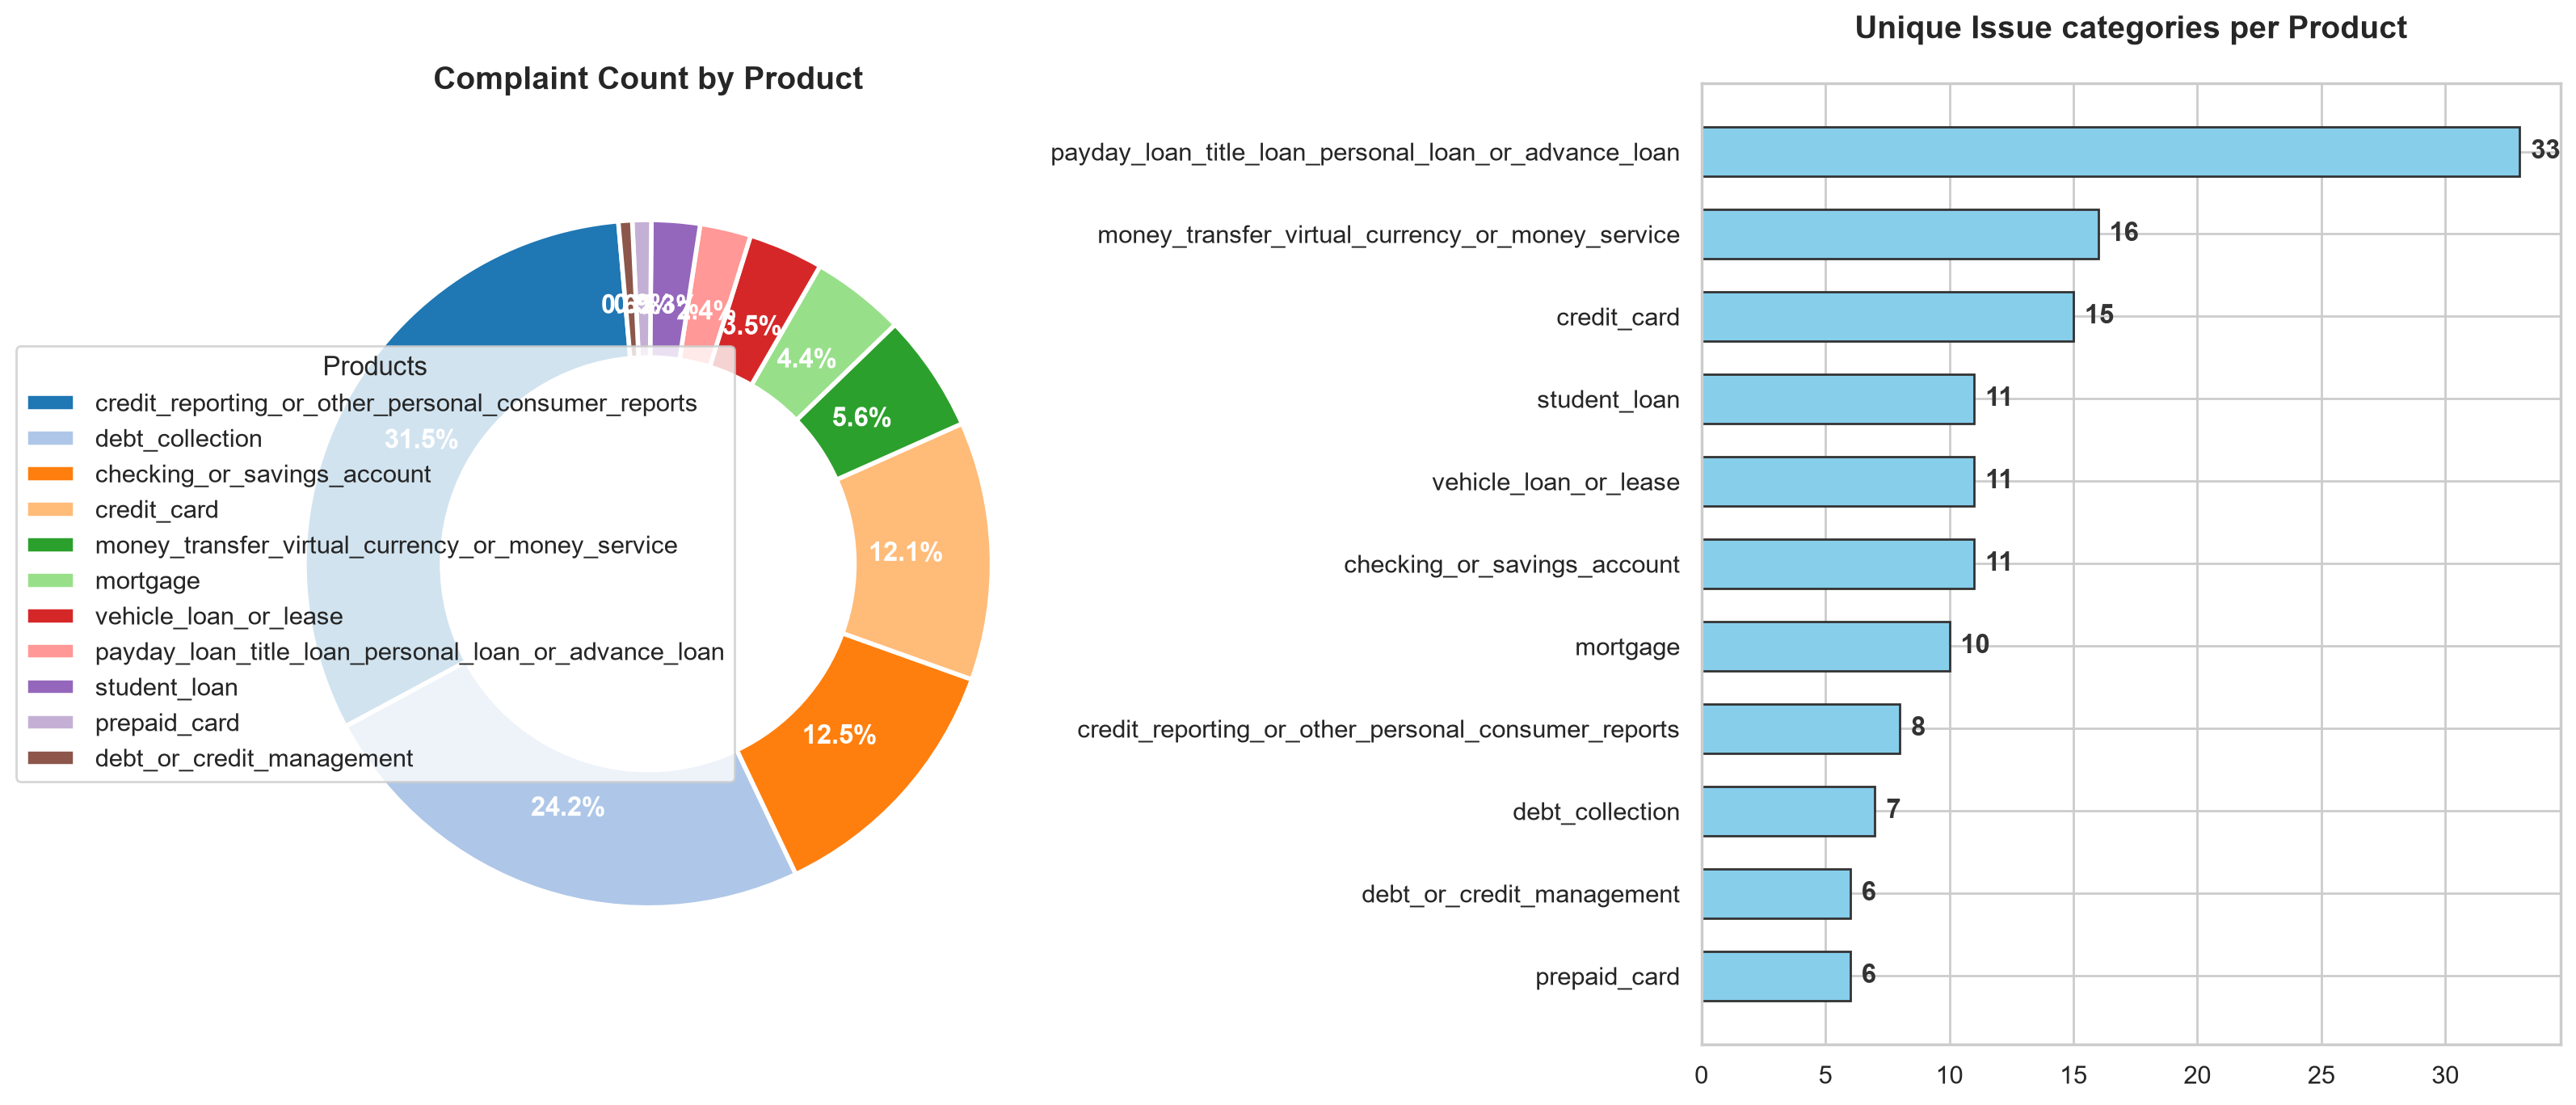

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
Summary = (
    pd.pivot_table(Data_Narrative,index='Product',aggfunc={'SubProduct':'nunique','Narrative':'count','Issue':'nunique'},sort=False).sort_values('Narrative',ascending=False),
    pd.pivot_table(Data_Narrative,index='Issue',aggfunc={'SubIssue':'nunique','Narrative':'count'},sort=False).sort_values('Narrative',ascending=False)
)
%config InlineBackend.figure_format = 'retina'
sns.set_theme(style='whitegrid') 
fig, axes = plt.subplots(1, 2, figsize=(16,7))

# --- PLOT 1: PIE CHART ---
df_pie = Summary[0]['Narrative'].sort_values(ascending=False)
colors = sns.color_palette('tab20',len(df_pie))
wedges,texts,autotexts = axes[0].pie(
    Summary[0]['Narrative'],
    autopct='%1.1f%%',
    startangle=95,
    colors=colors,
    textprops=dict(color='w',weight='bold'),
    pctdistance=0.75,
    wedgeprops=dict(width=0.4,edgecolor='w',linewidth=2) 
)
axes[0].legend(
    wedges, Summary[0].index,
    title='Products',
    loc='center left',
    bbox_to_anchor=(-0.25,0.5),
    frameon=True
)
axes[0].set_title('Complaint Counts by Product',fontsize=14,pad=20,weight='bold')
# --- ---
# --- PLOT 2: HORIZONTAL BAR CHART ---
df_bars = Summary[0]['Issue'].sort_values(ascending=True)
bars = axes[1].barh(
    df_bars.index, 
    df_bars, 
    color='skyblue', 
    edgecolor='#333333',
    linewidth=1,
    height=0.6
)
axes[1].set_title('Unique Issue categories per Product',fontsize=14,pad=20,weight='bold')
axes[1].set_ylabel('',fontsize=11) 
axes[1].bar_label(bars,padding=5,weight='bold',color='#333333')
# --- ---

plt.tight_layout()
plt.show()

## Let's count... 
Let us start with a simple idea: identify characteristic keywords—words that occur frequently within a particular complaint class but are relatively uncommon across other complaint classes. This can be achieved using [`class-based TF-IDF`](https://www.maartengrootendorst.com/blog/ctfidf/).

In [ ]:
from my_scripts import ClassKeywordExtractor

cTfIdf = ClassKeywordExtractor.TopK_cTFIDF(ngram_range=(1,1),stop_words=MASK_Names,exclude_pos=ClassKeywordExtractor.POS_ALL-{'NOUN','PROPN','NUM'})
Top_Keywords_1 = cTfIdf.fit_transform(Data_Narrative['Narrative'],Data_Narrative['Product'])
Top_Keywords_1

,Top_1,Top_2,Top_3,Top_4,Top_5,Top_6,Top_7,Top_8,Top_9,Top_10,Top_11,Top_12,Top_13,Top_14,Top_15,Top_16,Top_17,Top_18,Top_19,Top_20
credit_reporting_or_other_personal_consumer_reports,559.72,challenged,501.203,501.211,knowingly,nrs,assumed,provable,if,unproven,generallf,deptedxxxx,1770,lexisnexis,tu,edxxxx,addresses,1788.13,cccraa,649.375
money_transfer_virtual_currency_or_money_service,coinbase,zelle,kraken,robinhood,crypto,moneygram,crypto.com,skrill,blockchain,binance,coinbases,token,friends,meta,venmos,mercari,taptap,eth,gemini,puppy
debt_collection,1618d,credence,resurgent,caine,weiner,transworld,coll,jeffcapsys,pra,sunrise,syst,mcm,cred,fco,halsted,i.c.,oaks,procollect,tsi,aldous
checking_or_savings_account,marcus,schwab,optum,openbank,albert,etrade,stanley,novo,1005.6,robinhood,charles,betterment,webster,netspend,mask_pii('email_subject,secu,everbank,cit,229.13,xxxxauto
credit_card,barclay,fnbo,elan,aadvantage,cardmember,avant,robinhood,jetblue,nordstrom,quicksilver,kohls,lowes,lowe,wayfair,taxi,macy,savor,indigo,fortiva,citicard
debt_or_credit_management,americor,wentworth,jg,beyond,cordoba,saint,telemarketing,deuda,clearone,subparagraph,alperstein,jgw,cero,grt,clg,americors,cds,reliefs,weststar,croa
vehicle_loan_or_lease,exeter,kia,hyundai,carmax,bmw,ford,gls,carvana,stellantis,allys,mazda,mercedes,benz,odometer,vw,lendmark,veros,cnac,volkswagen,cps
mortgage,sps,newrez,phh,cooper,selene,pennymac,mr.,pmi,carrington,onity,cmg,qwr,amerihome,1024.41,mortgages,1024.35,lakeview,fay,uwm,recast
prepaid_card,netspend,vanilla,way2go,blackhawk,incomm,edd,conduent,reliacard,onbe,giftcard,reauthorization,skylight,bankofamerica,dailypay,netspends,comdata,networks,irp,northlane,crypto.com
student_loan,idr,edfinancial,cri,ibr,aes,firstmark,driven,studentaid.gov,paye,pheaa,educations,mohelas,tpd,sloan,ascent,maes,nelnets,fafsa,scholarship,tepslf


In [ ]:
cTfIdf2 = ClassKeywordExtractor.TopK_cTFIDF(ngram_range=(2,3),stop_words=MASK_Names)
Top_Keywords_2to4 = cTfIdf2.fit_transform(Data_Narrative['Narrative'],Data_Narrative['Product'])
Top_Keywords_2to4

,Top_1,Top_2,Top_3,Top_4,Top_5,Top_6,Top_7,Top_8,Top_9,Top_10,Top_11,Top_12,Top_13,Top_14,Top_15,Top_16,Top_17,Top_18,Top_19,Top_20
credit_reporting_or_other_personal_consumer_reports,impair efficiency,impair efficiency banking,efficiency banking,efficiency banking system,banking system violation,reporting method,undermine public,unauthorized account credit,u.s. code 1681,banking system unfair,report impair efficiency,system unfair,report impair,credit report impair,banking system dependent,system dependent,dependent fair accurate,dependent fair,system dependent fair,reporting inaccurate credit
money_transfer_virtual_currency_or_money_service,western union,complaint cash app,cash app block,recipient account,coinbase account,app block inc.,wallet address,fund paypal,venmo account,paypal customer,fraud platform,requirement electronic,platform leave,effective measure,comply error,resolution requirement electronic,platform leave account,comply error resolution,requirement electronic fund,customer service unfair
debt_collection,collector report credit,consumer report violation,file right fair,credit file right,credit account research,number report credit,disclosure investigation consumer,credit act u.s,act u.s,act u.s code,u.s code,code 1618d,u.s code 1618d,1618d disclosure,1618d disclosure investigation,code 1618d disclosure,license collect debt,debt delete,validation include original,exercise right fdcpa
checking_or_savings_account,mobile deposit,promotional bonus,fargo deny claim,atm deposit,fund availability,provisional credit investigation,e trade,receive bonus,attempt deposit,atm machine,qualify direct deposit,qualify direct,receive provisional credit,receive provisional,transaction chime,day deposit,card pin,atm transaction,atm locate,deposit hold
credit_card,promotional balance,citi card,citi credit card,defer interest charge,issue synchrony,chase sapphire,earn reward,citibank credit card,issue synchrony bank,0 apr,credit limit increase,bonus mile,credit limit reduction,reduce credit limit,apple card account,request citi,carecredit account,sapphire reserve,interest promotion,dispute citi
debt_or_credit_management,national debt relief,jg wentworth,beyond finance,item block remove,need item block,right consumer fcra,usc 605b.,15 usc 605b.,item block,consumer fcra 15,consumer fcra,credit saint,enrol debt settlement,usc 605b. report,report need item,605b. report,information report need,605b. report unauthorized,legal group,remove report possible
vehicle_loan_or_lease,exeter finance,toyota financial,kia finance,toyota financial services,gap insurance,one auto finance,global lending,td auto,hyundai motor,voluntary surrender,breach peace,complaint regard auto,hyundai motor finance,westlake financial services,td auto finance,carmax auto,motor credit,honda financial,register vehicle,repossession company
mortgage,freedom mortgage,escrow analysis,mr. cooper,escrow shortage,mortgage assistance,foreclosure activity,shellpoint mortgage,successor interest,phh mortgage,escrow balance,selene finance,flood insurance,shellpoint mortgage servicing,escrow payment,regard mortgage,partial claim,dual tracking,planet home,home lending,planet home lending
prepaid_card,direct express,money network,express gift,american express gift,express gift card,vanilla gift,amex gift,amex gift card,vanilla gift card,vanilla visa,blackhawk network,visa gift,visa gift card,prepay debit,way2go card,attempt use card,prepay debit card,prepaid gift,card gift,prepaid gift card
student_loan,qualifying payment,borrower defense,private student,private student loan,income drive,drive repayment,income drive repayment,public service loan,service loan forgiveness,call mohela,buyback request,forgiveness pslf,save plan,loan forgiveness pslf,student loan servicer,drive repayment plan,service mohela,qualifying payment count,idr plan,repayment idr


Here, we list the top 20 characteristic keywords for each complaint class, separately for unigrams and for 2,3-grams. The key observations are as follows:
- As a purely frequency-based approach, c-TF-IDF tends to rank prominent company names within a particular product category (e.g.- Barclays, Americor, Coinbase, Western Union, Citi etc.) among the top keywords. Since the dataset already contains a dedicated Company Name field, these keywords provide little additional information.
- While complaint-specific phrases such as 'edd', 'unauthorized account credit', 'promotional bonus', 'private student loan', and 'escrow analysis' are successfully identified, n-gram fragmentation—seen in terms like 'impair efficiency', 'efficiency banking system', 'impair efficiency banking', and 'efficiency banking'—reveals the inability of a frequency-based model to capture the semantic similarity between expressions.
- Some extracted keywords are not self-explanatory without their surrounding context. For example, '559.72' refers to a provision of FCCPA that protects consumers from deceptive threats, but the keyword alone does not convey this meaning.

Considering these limitations, we use c-TF-IDF as a baseline and next proceed to embedding-based approaches.

## Can you read between the lines?